In [9]:
import os
import sys
import pandas as pd

# Ensure Python can import from ../src when running notebook from notebooks/
SRC_PATH = os.path.abspath("../src")
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

from seniority import is_tech_title, classify_seniority_hybrid

SENIORITY_ORDER = ["entry", "mid", "senior", "leadership"]

# Load cleaned dataset
df_all = pd.read_csv("../data/job_postings_clean.csv")
print(f"Loaded rows: {len(df_all):,}")


# Filter to tech subset
df = df_all[df_all["title"].apply(is_tech_title)].copy()
print(f"Tech subset rows: {len(df):,} ({len(df) / len(df_all) * 100:.2f}% of cleaned data)")

# Apply hybrid seniority classification on the tech subset
df["seniority"] = df.apply(
    lambda row: classify_seniority_hybrid(
        title=row["title"],
        clean_text=row["clean_text"],
        experience=row["experience"],
        qualifications=row["qualifications"],
    ),
    axis=1,
)

counts = df["seniority"].value_counts().reindex(SENIORITY_ORDER, fill_value=0)
percentages = (counts / counts.sum() * 100).round(2)

print("Seniority distribution (Tech subset):")
print(counts)
print("\nAs percentages (Tech subset):")
print(percentages)

# Guardrails for target range compliance
guardrails = {
    "entry": (28, 38),
    "mid": (40, 50),
    "senior": (15, 23),
    "leadership": (4, 8),
}

violations = []
for level, (lo, hi) in guardrails.items():
    value = float(percentages.get(level, 0.0))
    if not (lo <= value <= hi):
        violations.append(f"{level}: {value:.2f}% (expected {lo}-{hi}%)")

if violations:
    raise ValueError(
        "Seniority distribution guardrails failed for tech subset:\n"
        + "\n".join(violations)
    )

print("\nGuardrails passed.")

# Save tech-specific dataset with seniority labels
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/job_postings_tech_with_seniority.csv", index=False)
print("Saved tech labeled dataset -> ../data/job_postings_tech_with_seniority.csv")

# Save one tech file per seniority level
for level in SENIORITY_ORDER:
    subset = df[df["seniority"] == level].copy()

    # deduplicate on embedding_text so repeated templates do not dominate training
    subset = (
        subset.groupby("embedding_text", group_keys=False)
        .head(20)
        .copy()
    )

    out_path = f"../data/job_postings_tech_{level}.csv"
    subset.to_csv(out_path, index=False)
    print(f"Saved tech {level}: {len(subset):,} rows -> {out_path}")


Loaded rows: 1,615,940
Tech subset rows: 393,676 (24.36% of cleaned data)
Seniority distribution (Tech subset):
seniority
entry         130834
mid           173904
senior         68001
leadership     20937
Name: count, dtype: int64

As percentages (Tech subset):
seniority
entry         33.23
mid           44.17
senior        17.27
leadership     5.32
Name: count, dtype: float64

Guardrails passed.
Saved tech labeled dataset -> ../data/job_postings_tech_with_seniority.csv
Saved tech entry: 80 rows -> ../data/job_postings_tech_entry.csv
Saved tech mid: 68 rows -> ../data/job_postings_tech_mid.csv
Saved tech senior: 72 rows -> ../data/job_postings_tech_senior.csv
Saved tech leadership: 8 rows -> ../data/job_postings_tech_leadership.csv


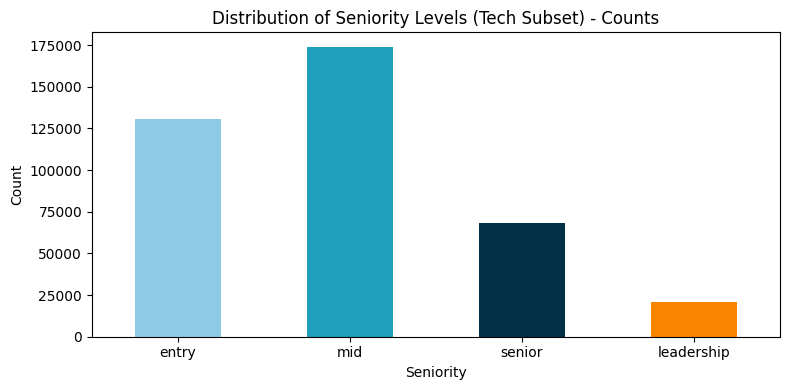

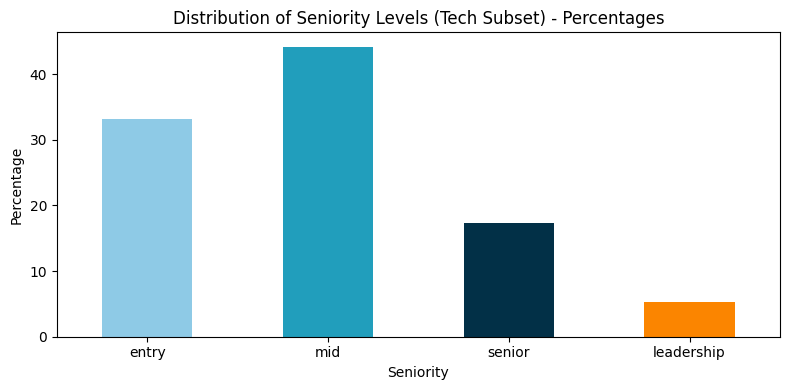

In [10]:
import matplotlib.pyplot as plt

SENIORITY_ORDER = ["entry", "mid", "senior", "leadership"]
counts = df["seniority"].value_counts().reindex(SENIORITY_ORDER, fill_value=0)
percentages = (counts / counts.sum() * 100).round(2)

# Count plot
plt.figure(figsize=(8, 4))
counts.plot(kind="bar", color=["#8ecae6", "#219ebc", "#023047", "#fb8500"])
plt.title("Distribution of Seniority Levels (Tech Subset) - Counts")
plt.xlabel("Seniority")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Percentage plot
plt.figure(figsize=(8, 4))
percentages.plot(kind="bar", color=["#8ecae6", "#219ebc", "#023047", "#fb8500"])
plt.title("Distribution of Seniority Levels (Tech Subset) - Percentages")
plt.xlabel("Seniority")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [11]:
# Word frequency per seniority (tech subset)
from collections import Counter

def get_top_words(text_series, n=20):
    values = text_series.dropna().astype(str)
    if values.empty:
        return []
    words = " ".join(values).split()
    if not words:
        return []
    return Counter(words).most_common(n)

SENIORITY_ORDER = ["entry", "mid", "senior", "leadership"]
for level in SENIORITY_ORDER:
    print(f"\nTop words for {level} (tech subset):")
    subset = df[df["seniority"] == level]
    if subset.empty:
        print("No rows available for this level.")
        continue
    print(get_top_words(subset["embedding_text"], 15))



Top words for entry (tech subset):
[('and', 742146), ('to', 169110), ('user', 136022), ('data', 103513), ('they', 99546), ('with', 95341), ('for', 84286), ('design', 82536), ('ensure', 79163), ('security', 77960), ('network', 75127), ('the', 70377), ('create', 64708), ('implement', 63545), ('maintain', 61188)]

Top words for mid (tech subset):
[('and', 1007194), ('to', 237900), ('user', 199297), ('they', 142338), ('data', 141033), ('with', 122474), ('network', 113757), ('for', 109677), ('ensure', 109426), ('design', 106351), ('security', 95740), ('the', 91792), ('create', 90565), ('implement', 88613), ('maintain', 87042)]

Top words for senior (tech subset):
[('and', 387903), ('to', 91872), ('user', 71786), ('data', 63556), ('they', 55135), ('with', 53419), ('security', 53405), ('for', 43525), ('design', 42709), ('ensure', 39250), ('network', 38219), ('software', 37352), ('create', 34815), ('maintain', 34322), ('the', 33586)]

Top words for leadership (tech subset):
[('and', 95336), (

In [12]:
# Compare word distributions (tech subset)
from collections import Counter
import matplotlib.pyplot as plt

def get_top_words_for_plot(text_series, n=15):
    values = text_series.dropna().astype(str)
    if values.empty:
        return []
    words = " ".join(values).split()
    if not words:
        return []
    return Counter(words).most_common(n)

def plot_top_words(level):
    subset = df[df["seniority"] == level]
    if subset.empty:
        print(f"Skipping {level}: no rows available.")
        return

    top = get_top_words_for_plot(subset["embedding_text"], 15)
    if not top:
        print(f"Skipping {level}: no words found.")
        return

    words, counts = zip(*top)

    plt.figure(figsize=(8, 5))
    plt.barh(words, counts, color="#219ebc")
    plt.title(f"Top Words: {level} (Tech Subset)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


